In [1]:
!pip install transformers datasets torch scikit-learn accelerate

In [2]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


In [3]:
df = pd.read_csv("dataset_news.csv")
df = df.dropna()

df.head()

,Judul Berita,Tanggal Berita,Tag,Link,Raw Clean (POS/NER),Sentiment Clean (Transformer),Sentiment Before Stopwords,Sentiment After Stopwords,Tokens Before Stopwords,Tokens After Stopwords,Sentence Tokens,Word Tokens,POS Tags,NER,Sentiment Classic Simple,Sentiment Classic Weighted,Sentiment Classic,Sentiment Transformer,Ground Truth
0,ASDP dan Operator Ferry Swasta Perkuat Data Ma...,8/12/2025 0:00,"ASDP, kapal ferry, manifest penumpang, operato...",https://money.kompas.com/read/2025/08/12/15391...,"JAKARTA, KOMPAS.com Manifest penumpang dan ken...","jakarta, kompas.com manifest penumpang dan ken...","jakarta , kompas.com manifest penumpang dan ke...",jakarta kompas com manifest tumpang kendara d...,"['jakarta', ',', 'kompas.com', 'manifest', 'pe...","['jakarta', '', 'kompas com', 'manifest', 'tum...","['JAKARTA, KOMPAS.com Manifest penumpang dan k...","['JAKARTA', ',', 'KOMPAS.com', 'Manifest', 'pe...","[('JAKARTA', 'PROPN'), (',', 'PUNCT'), ('KOMPA...","[{'entity_group': 'GPE', 'score': np.float32(0...",Positive,Positive,Positive,Negative,Positive
1,"Listrik di Pulau Enggano Sudah 24 Jam, Kapal F...",7/8/2025 0:00,"pulau enggano, Bio Solar, Pelabuhan Pulau Baai...",https://regional.kompas.com/read/2025/07/08/10...,"BENGKULU, KOMPAS.com Kepala Desa Kaana, Alamud...","bengkulu, kompas.com kepala desa kaana, alamud...","bengkulu , kompas.com kepala desa kaana , alam...",bengkulu kompas com kepala desa kaana alamud...,"['bengkulu', ',', 'kompas.com', 'kepala', 'des...","['bengkulu', '', 'kompas com', 'kepala', 'desa...","['BENGKULU, KOMPAS.com Kepala Desa Kaana, Alam...","['BENGKULU', ',', 'KOMPAS.com', 'Kepala', 'Des...","[('BENGKULU', 'PROPN'), (',', 'PUNCT'), ('KOMP...",[],Positive,Positive,Positive,Neutral,Positive
2,"Ombak Hingga 2,5 Meter Hambat Pencarian KMP Tu...",2025-07-03 02:09:12+00:00,"Berita Terkini, Berita Hari Ini, Berita Harian...",https://video.kompas.com/watch/1858879/ombak-h...,"KMP Tunu Pratama Jaya tenggelam di Selat Bali,...","kmp tunu pratama jaya tenggelam di selat bali,...",kmp tunu pratama jaya tenggelam di selat bali ...,kmp tunu pratama jaya tenggelam selat bal rab...,"['kmp', 'tunu', 'pratama', 'jaya', 'tenggelam'...","['kmp', 'tunu', 'pratama', 'jaya', 'tenggelam'...",['KMP Tunu Pratama Jaya tenggelam di Selat Bal...,"['KMP', 'Tunu', 'Pratama', 'Jaya', 'tenggelam'...","[('KMP', 'PROPN'), ('Tunu', 'PROPN'), ('Pratam...","[{'entity_group': 'PRD', 'score': np.float32(0...",Negative,Negative,Negative,Negative,Negative
3,Rute Ferry Batam–Johor Direncanakan Aktif Tahu...,5/23/2025 0:00,"kapal ferry, batam johor bahru ferry schedule,...",https://money.kompas.com/read/2025/05/23/22053...,KOMPAS.com PT Angkutan Sungai Danau dan Penyeb...,kompas.com pt angkutan sungai danau dan penyeb...,kompas.com pt angkutan sungai danau dan penyeb...,kompas com pt angkut sungai danau seberang asd...,"['kompas.com', 'pt', 'angkutan', 'sungai', 'da...","['kompas com', 'pt', 'angkut', 'sungai', 'dana...",['KOMPAS.com PT Angkutan Sungai Danau dan Peny...,"['KOMPAS.com', 'PT', 'Angkutan', 'Sungai', 'Da...","[('KOMPAS.com', 'PROPN'), ('PT', 'PROPN'), ('A...","[{'entity_group': 'ORG', 'score': np.float32(0...",Positive,Positive,Positive,Negative,Positive
4,"Menyeberangi Danau Toba, Perjalanan Naik Kapal...",5/16/2025 0:00,"kapal dari ajibata ke tomok, kapal ferry pelab...",https://travel.kompas.com/read/2025/05/16/0707...,KOMPAS.com Kala melihat kapal berwarna hijau t...,kompas.com kala melihat kapal berwarna hijau t...,kompas.com kala melihat kapal berwarna hijau t...,kompas com kapal warna hijau sandar labuh kem...,"['kompas.com', 'kala', 'melihat', 'kapal', 'be...","['kompas com', 'kapal', 'warna', 'hijau', 'san...",['KOMPAS.com Kala melihat kapal berwarna hijau...,"['KOMPAS.com', 'Kala', 'melihat', 'kapal', 'be...","[('KOMPAS.com', 'PROPN'), ('Kala', 'PROPN'), (...",[],Positive,Positive,Positive,Neutral,Positive


In [4]:
df["Ground Truth"].unique()

array(['Positive', 'Negative', 'Neutral'], dtype=object)

In [5]:
label_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["Ground Truth"] = df["Ground Truth"].map(label_mapping)


In [6]:
df

,Judul Berita,Tanggal Berita,Tag,Link,Raw Clean (POS/NER),Sentiment Clean (Transformer),Sentiment Before Stopwords,Sentiment After Stopwords,Tokens Before Stopwords,Tokens After Stopwords,Sentence Tokens,Word Tokens,POS Tags,NER,Sentiment Classic Simple,Sentiment Classic Weighted,Sentiment Classic,Sentiment Transformer,Ground Truth
0,ASDP dan Operator Ferry Swasta Perkuat Data Ma...,8/12/2025 0:00,"ASDP, kapal ferry, manifest penumpang, operato...",https://money.kompas.com/read/2025/08/12/15391...,"JAKARTA, KOMPAS.com Manifest penumpang dan ken...","jakarta, kompas.com manifest penumpang dan ken...","jakarta , kompas.com manifest penumpang dan ke...",jakarta kompas com manifest tumpang kendara d...,"['jakarta', ',', 'kompas.com', 'manifest', 'pe...","['jakarta', '', 'kompas com', 'manifest', 'tum...","['JAKARTA, KOMPAS.com Manifest penumpang dan k...","['JAKARTA', ',', 'KOMPAS.com', 'Manifest', 'pe...","[('JAKARTA', 'PROPN'), (',', 'PUNCT'), ('KOMPA...","[{'entity_group': 'GPE', 'score': np.float32(0...",Positive,Positive,Positive,Negative,2
1,"Listrik di Pulau Enggano Sudah 24 Jam, Kapal F...",7/8/2025 0:00,"pulau enggano, Bio Solar, Pelabuhan Pulau Baai...",https://regional.kompas.com/read/2025/07/08/10...,"BENGKULU, KOMPAS.com Kepala Desa Kaana, Alamud...","bengkulu, kompas.com kepala desa kaana, alamud...","bengkulu , kompas.com kepala desa kaana , alam...",bengkulu kompas com kepala desa kaana alamud...,"['bengkulu', ',', 'kompas.com', 'kepala', 'des...","['bengkulu', '', 'kompas com', 'kepala', 'desa...","['BENGKULU, KOMPAS.com Kepala Desa Kaana, Alam...","['BENGKULU', ',', 'KOMPAS.com', 'Kepala', 'Des...","[('BENGKULU', 'PROPN'), (',', 'PUNCT'), ('KOMP...",[],Positive,Positive,Positive,Neutral,2
2,"Ombak Hingga 2,5 Meter Hambat Pencarian KMP Tu...",2025-07-03 02:09:12+00:00,"Berita Terkini, Berita Hari Ini, Berita Harian...",https://video.kompas.com/watch/1858879/ombak-h...,"KMP Tunu Pratama Jaya tenggelam di Selat Bali,...","kmp tunu pratama jaya tenggelam di selat bali,...",kmp tunu pratama jaya tenggelam di selat bali ...,kmp tunu pratama jaya tenggelam selat bal rab...,"['kmp', 'tunu', 'pratama', 'jaya', 'tenggelam'...","['kmp', 'tunu', 'pratama', 'jaya', 'tenggelam'...",['KMP Tunu Pratama Jaya tenggelam di Selat Bal...,"['KMP', 'Tunu', 'Pratama', 'Jaya', 'tenggelam'...","[('KMP', 'PROPN'), ('Tunu', 'PROPN'), ('Pratam...","[{'entity_group': 'PRD', 'score': np.float32(0...",Negative,Negative,Negative,Negative,0
3,Rute Ferry Batam–Johor Direncanakan Aktif Tahu...,5/23/2025 0:00,"kapal ferry, batam johor bahru ferry schedule,...",https://money.kompas.com/read/2025/05/23/22053...,KOMPAS.com PT Angkutan Sungai Danau dan Penyeb...,kompas.com pt angkutan sungai danau dan penyeb...,kompas.com pt angkutan sungai danau dan penyeb...,kompas com pt angkut sungai danau seberang asd...,"['kompas.com', 'pt', 'angkutan', 'sungai', 'da...","['kompas com', 'pt', 'angkut', 'sungai', 'dana...",['KOMPAS.com PT Angkutan Sungai Danau dan Peny...,"['KOMPAS.com', 'PT', 'Angkutan', 'Sungai', 'Da...","[('KOMPAS.com', 'PROPN'), ('PT', 'PROPN'), ('A...","[{'entity_group': 'ORG', 'score': np.float32(0...",Positive,Positive,Positive,Negative,2
4,"Menyeberangi Danau Toba, Perjalanan Naik Kapal...",5/16/2025 0:00,"kapal dari ajibata ke tomok, kapal ferry pelab...",https://travel.kompas.com/read/2025/05/16/0707...,KOMPAS.com Kala melihat kapal berwarna hijau t...,kompas.com kala melihat kapal berwarna hijau t...,kompas.com kala melihat kapal berwarna hijau t...,kompas com kapal warna hijau sandar labuh kem...,"['kompas.com', 'kala', 'melihat', 'kapal', 'be...","['kompas com', 'kapal', 'warna', 'hijau', 'san...",['KOMPAS.com Kala melihat kapal berwarna hijau...,"['KOMPAS.com', 'Kala', 'melihat', 'kapal', 'be...","[('KOMPAS.com', 'PROPN'), ('Kala', 'PROPN'), (...",[],Positive,Positive,Positive,Neutral,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,ASDP Waspadai Cuaca Buruk Ganggu Penyeberangan...,12/23/2022 12:32

In [7]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["Raw Clean (POS/NER)"].tolist(),
    df["Ground Truth"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["Ground Truth"]
)


In [8]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [10]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)


In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs"
)


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)


/tmp/ipython-input-2278256107.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [13]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hasnadaffa-u (hasnadaffa-u-its) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


TrainOutput(global_step=45, training_loss=0.6557948218451606, metrics={'train_runtime': 23.6862, 'train_samples_per_second': 28.878, 'train_steps_per_second': 1.9, 'total_flos': 44992394431488.0, 'train_loss': 0.6557948218451606, 'epoch': 3.0})

In [14]:
from sklearn.metrics import classification_report

predictions = trainer.predict(val_dataset)
y_pred = predictions.predictions.argmax(axis=1)

print(classification_report(val_labels, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.7368    0.8750    0.8000        16
           1     0.8571    0.7200    0.7826        25
           2     0.6471    0.6875    0.6667        16

    accuracy                         0.7544        57
   macro avg     0.7470    0.7608    0.7498        57
weighted avg     0.7644    0.7544    0.7549        57



In [15]:
trainer.save_model("bert-sentiment-indonesia")
tokenizer.save_pretrained("bert-sentiment-indonesia")


('bert-sentiment-indonesia/tokenizer_config.json',
 'bert-sentiment-indonesia/special_tokens_map.json',
 'bert-sentiment-indonesia/vocab.txt',
 'bert-sentiment-indonesia/added_tokens.json',
 'bert-sentiment-indonesia/tokenizer.json')

## **SKENARIO 1 — FULL FINE-TUNING (BASELINE)**

In [16]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "indobenchmark/indobert-base-p1"

model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
trainer_full = Trainer(
    model=model_full,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)


/tmp/ipython-input-1313332578.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_full = Trainer(


In [18]:
trainer_full.train()


Step,Training Loss


TrainOutput(global_step=45, training_loss=0.6858855353461372, metrics={'train_runtime': 6.6166, 'train_samples_per_second': 103.376, 'train_steps_per_second': 6.801, 'total_flos': 44992394431488.0, 'train_loss': 0.6858855353461372, 'epoch': 3.0})

In [19]:
pred_full = trainer_full.predict(val_dataset)
y_pred_full = pred_full.predictions.argmax(axis=1)


## **SKENARIO 2 — FREEZE BERT + TRAIN CLASSIFIER**

In [20]:
model_freeze = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

# Freeze semua layer BERT
for param in model_freeze.bert.parameters():
    param.requires_grad = False


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
trainer_freeze = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)


/tmp/ipython-input-2563418098.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_freeze = Trainer(


In [22]:
trainer_freeze.train()


Step,Training Loss


TrainOutput(global_step=45, training_loss=1.1227227952745227, metrics={'train_runtime': 2.6926, 'train_samples_per_second': 254.03, 'train_steps_per_second': 16.712, 'total_flos': 44992394431488.0, 'train_loss': 1.1227227952745227, 'epoch': 3.0})

In [23]:
pred_freeze = trainer_freeze.predict(val_dataset)
y_pred_freeze = pred_freeze.predictions.argmax(axis=1)


In [24]:
from sklearn.metrics import classification_report

print("=== FULL FINE-TUNING ===")
print(classification_report(val_labels, y_pred_full, digits=4))

print("\n=== FREEZE BERT ENCODER ===")
print(classification_report(val_labels, y_pred_freeze, digits=4))


=== FULL FINE-TUNING ===
              precision    recall  f1-score   support

           0     0.7222    0.8125    0.7647        16
           1     0.8095    0.6800    0.7391        25
           2     0.5556    0.6250    0.5882        16

    accuracy                         0.7018        57
   macro avg     0.6958    0.7058    0.6974        57
weighted avg     0.7137    0.7018    0.7040        57


=== FREEZE BERT ENCODER ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        16
           1     0.4510    0.9200    0.6053        25
           2     0.3333    0.1250    0.1818        16

    accuracy                         0.4386        57
   macro avg     0.2614    0.3483    0.2624        57
weighted avg     0.2914    0.4386    0.3165        57



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def summarize_metrics(y_true, y_pred, name):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    return {
        "Model": name,
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1-score": round(f, 4)
    }

results = pd.DataFrame([
    summarize_metrics(val_labels, y_pred_full, "Full Fine-Tuning"),
    summarize_metrics(val_labels, y_pred_freeze, "Freeze Encoder")
])

results


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Precision,Recall,F1-score
0,Full Fine-Tuning,0.6958,0.7058,0.6974
1,Freeze Encoder,0.2614,0.3483,0.2624


In [26]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def train_with_epoch(epoch):
    training_args = TrainingArguments(
        output_dir=f"./results_epoch_{epoch}",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=epoch,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_dir=f"./logs_epoch_{epoch}",
        report_to="none"
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer
    )

    trainer.train()

    preds = trainer.predict(val_dataset)
    y_pred = preds.predictions.argmax(axis=1)

    p, r, f, _ = precision_recall_fscore_support(
        val_labels,
        y_pred,
        average="macro"
    )

    return {
        "Epoch": epoch,
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1-score": round(f, 4)
    }


In [27]:
epochs = [3, 5, 7, 10]
results = []

for e in epochs:
    print(f"\nTraining dengan epoch = {e}")
    results.append(train_with_epoch(e))



Training dengan epoch = 3


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3553401257.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss



Training dengan epoch = 5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3553401257.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3553401257.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss



Training dengan epoch = 10


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3553401257.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


In [28]:
results_df = pd.DataFrame(results)
results_df

,Epoch,Precision,Recall,F1-score
0,3,0.6958,0.7058,0.6974
1,5,0.7271,0.7325,0.7295
2,7,0.7143,0.7267,0.7170
3,10,0.7470,0.7608,0.7498


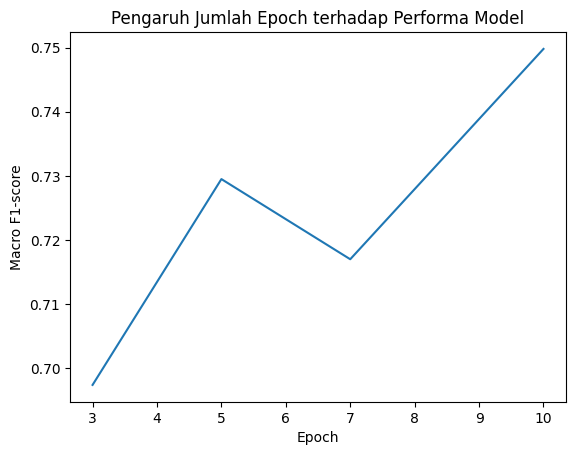

In [29]:
import matplotlib.pyplot as plt

plt.plot(results_df["Epoch"], results_df["F1-score"])
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Pengaruh Jumlah Epoch terhadap Performa Model")
plt.show()


# **EKSPERIMEN BERT: TUNING EPOCH, LEARNING RATE, & MAX LENGTH**

In [30]:
import pandas as pd
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import precision_recall_fscore_support


In [31]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
NUM_LABELS = 3


In [32]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.labels)


In [33]:
def run_experiment(epoch, lr, max_len):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_enc = tokenizer(
        train_texts,
        truncation=True,
        padding=True,
        max_length=max_len,
        return_token_type_ids=False
    )

    val_enc = tokenizer(
        val_texts,
        truncation=True,
        padding=True,
        max_length=max_len,
        return_token_type_ids=False
    )

    train_ds = SentimentDataset(train_enc, train_labels)
    val_ds = SentimentDataset(val_enc, val_labels)

    training_args = TrainingArguments(
        output_dir=f"./exp_e{epoch}_lr{lr}_len{max_len}",
        num_train_epochs=epoch,
        learning_rate=lr,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none"
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer
    )

    trainer.train()

    preds = trainer.predict(val_ds)
    y_pred = preds.predictions.argmax(axis=1)

    p, r, f, _ = precision_recall_fscore_support(
        val_labels, y_pred, average="macro"
    )

    return {
        "Epoch": epoch,
        "Learning Rate": lr,
        "Max Length": max_len,
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1-score": round(f, 4)
    }


In [34]:
epochs = [3, 5, 7]
learning_rates = [1e-5, 2e-5]
max_lengths = [128, 256]

results = []

for e in epochs:
    for lr in learning_rates:
        for ml in max_lengths:
            print(f"\nRunning: epoch={e}, lr={lr}, max_len={ml}")
            results.append(run_experiment(e, lr, ml))



Running: epoch=3, lr=1e-05, max_len=128


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1757452998.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss



Running: epoch=3, lr=1e-05, max_len=256


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1757452998.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1757452998.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.334800



Running: epoch=7, lr=2e-05, max_len=256


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1757452998.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.402200


In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-score", ascending=False)
results_df


,Epoch,Learning Rate,Max Length,Precision,Recall,F1-score
5,5,0.00001,256,0.7667,0.7683,0.7543
10,7,0.00002,128,0.7487,0.7608,0.7511
11,7,0.00002,256,0.7460,0.7533,0.7487
7,5,0.00002,256,0.7484,0.7533,0.7481
8,7,0.00001,128,0.7465,0.7533,0.7478
9,7,0.00001,256,0.7336,0.7400,0.7330
3,3,0.00002,256,0.7269,0.7325,0.7285
4,5,0.00001,128,0.7238,0.7325,0.7252
0,3,0.00001,128,0.7279,0.7250,0.7232
6,5,0.00002,128,0.6977,0.7058,0.6998


In [ ]:
best_config = results_df.iloc[0]
best_config


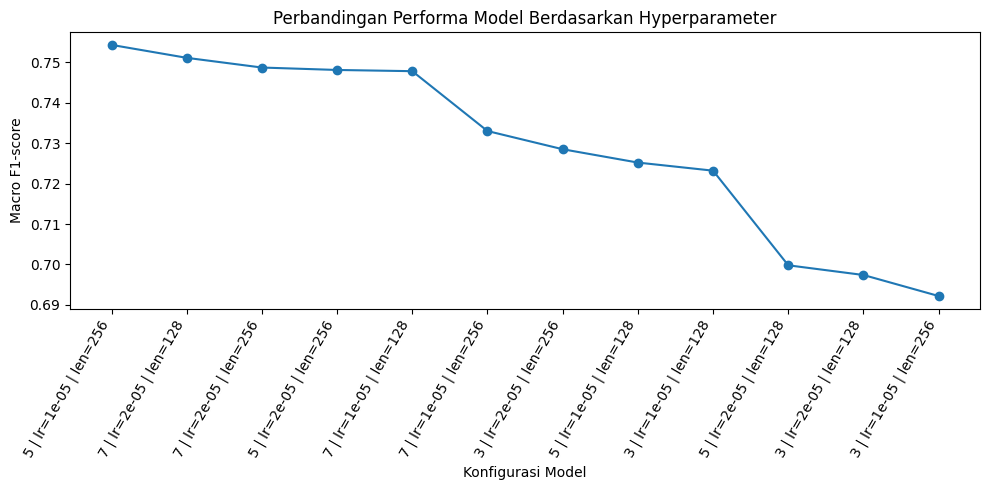

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    range(len(results_df)),
    results_df["F1-score"],
    marker="o"
)

plt.xticks(
    range(len(results_df)),
    results_df["Epoch"].astype(str)
    + " | lr=" + results_df["Learning Rate"].astype(str)
    + " | len=" + results_df["Max Length"].astype(str),
    rotation=60,
    ha="right"
)

plt.xlabel("Konfigurasi Model")
plt.ylabel("Macro F1-score")
plt.title("Perbandingan Performa Model Berdasarkan Hyperparameter")
plt.tight_layout()
plt.show()


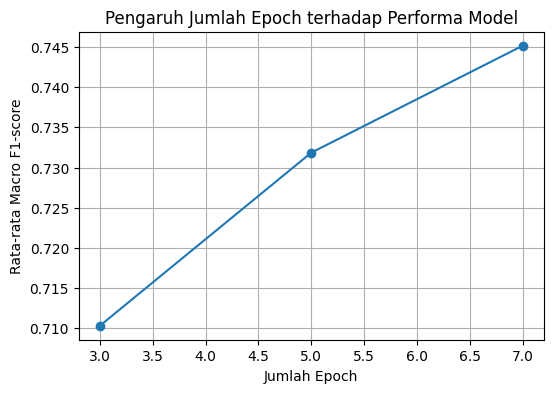

In [37]:
epoch_group = results_df.groupby("Epoch")["F1-score"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(epoch_group["Epoch"], epoch_group["F1-score"], marker="o")
plt.xlabel("Jumlah Epoch")
plt.ylabel("Rata-rata Macro F1-score")
plt.title("Pengaruh Jumlah Epoch terhadap Performa Model")
plt.grid(True)
plt.show()


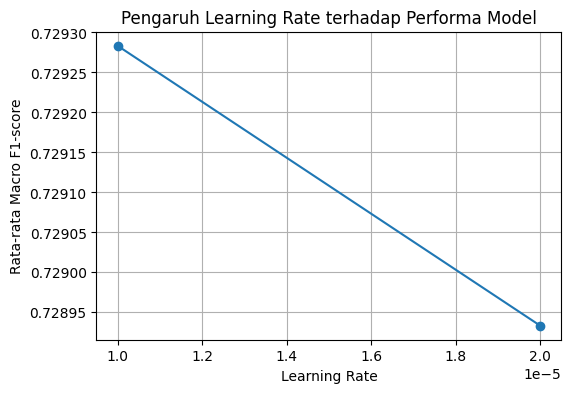

In [38]:
lr_group = results_df.groupby("Learning Rate")["F1-score"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(lr_group["Learning Rate"], lr_group["F1-score"], marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Rata-rata Macro F1-score")
plt.title("Pengaruh Learning Rate terhadap Performa Model")
plt.grid(True)
plt.show()


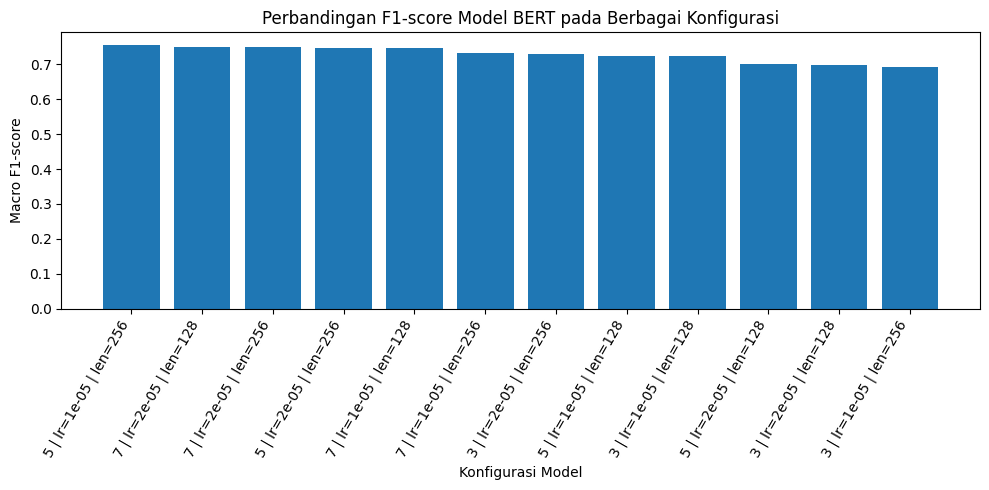

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(
    range(len(results_df)),
    results_df["F1-score"]
)

plt.xticks(
    range(len(results_df)),
    results_df["Epoch"].astype(str)
    + " | lr=" + results_df["Learning Rate"].astype(str)
    + " | len=" + results_df["Max Length"].astype(str),
    rotation=60,
    ha="right"
)

plt.ylabel("Macro F1-score")
plt.xlabel("Konfigurasi Model")
plt.title("Perbandingan F1-score Model BERT pada Berbagai Konfigurasi")
plt.tight_layout()
plt.show()


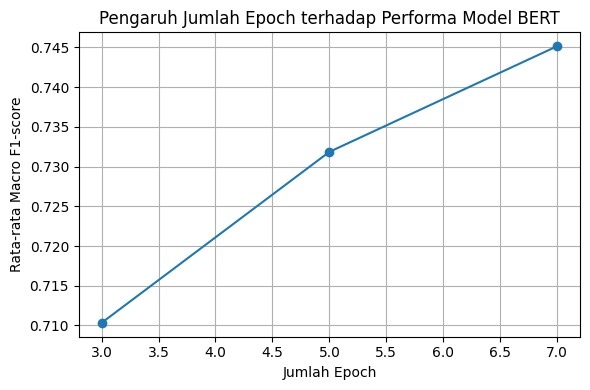

In [40]:
epoch_group = results_df.groupby("Epoch")["F1-score"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(
    epoch_group["Epoch"],
    epoch_group["F1-score"],
    marker="o"
)

plt.xlabel("Jumlah Epoch")
plt.ylabel("Rata-rata Macro F1-score")
plt.title("Pengaruh Jumlah Epoch terhadap Performa Model BERT")
plt.grid(True)
plt.tight_layout()
plt.show()


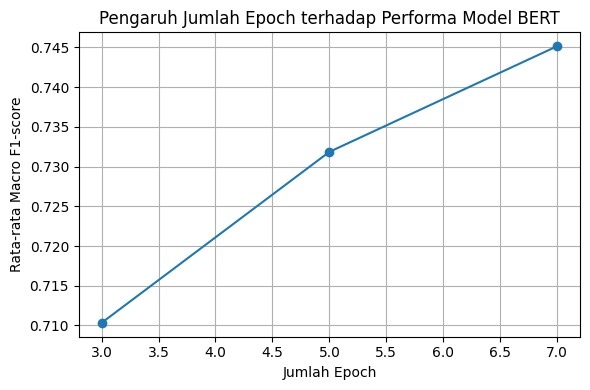

In [41]:
epoch_group = results_df.groupby("Epoch")["F1-score"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(
    epoch_group["Epoch"],
    epoch_group["F1-score"],
    marker="o"
)

plt.xlabel("Jumlah Epoch")
plt.ylabel("Rata-rata Macro F1-score")
plt.title("Pengaruh Jumlah Epoch terhadap Performa Model BERT")
plt.grid(True)
plt.tight_layout()
plt.show()


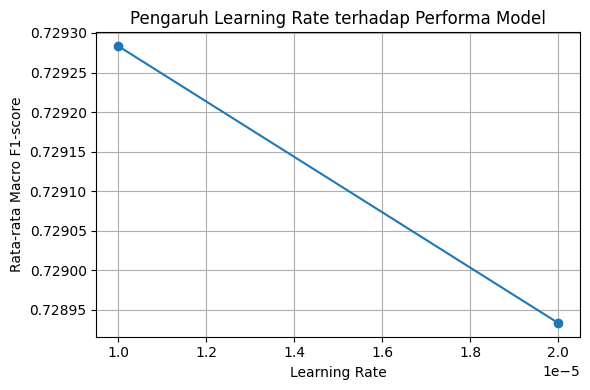

In [42]:
lr_group = results_df.groupby("Learning Rate")["F1-score"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(
    lr_group["Learning Rate"],
    lr_group["F1-score"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Rata-rata Macro F1-score")
plt.title("Pengaruh Learning Rate terhadap Performa Model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
best_config = results_df.iloc[0]
best_config


,5
Epoch,5.00000
Learning Rate,0.00001
Max Length,256.00000
Precision,0.76670
Recall,0.76830
F1-score,0.75430


In [44]:
best_epoch = int(best_config["Epoch"])
best_lr = best_config["Learning Rate"]
best_len = int(best_config["Max Length"])

# Tokenisasi ulang
best_train_enc = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=best_len,
    return_token_type_ids=False
)

best_val_enc = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=best_len,
    return_token_type_ids=False
)

best_train_ds = SentimentDataset(best_train_enc, train_labels)
best_val_ds = SentimentDataset(best_val_enc, val_labels)

training_args = TrainingArguments(
    output_dir="./best_model",
    num_train_epochs=best_epoch,
    learning_rate=best_lr,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    report_to="none"
)

best_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

trainer = Trainer(
    model=best_model,
    args=training_args,
    train_dataset=best_train_ds,
    eval_dataset=best_val_ds,
    tokenizer=tokenizer
)

trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3159525694.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


TrainOutput(global_step=75, training_loss=0.6102066548665365, metrics={'train_runtime': 13.2702, 'train_samples_per_second': 85.907, 'train_steps_per_second': 5.652, 'total_flos': 149974648104960.0, 'train_loss': 0.6102066548665365, 'epoch': 5.0})

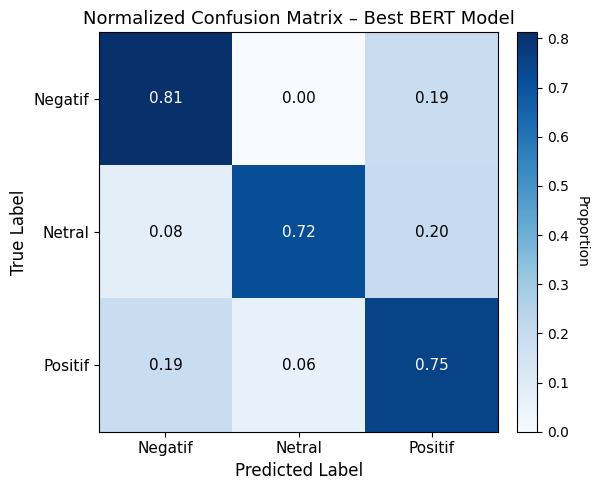

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Prediksi
preds = trainer.predict(best_val_ds)
y_pred = preds.predictions.argmax(axis=1)

# Confusion matrix (normalized)
cm = confusion_matrix(val_labels, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

labels = ["Negatif", "Netral", "Positif"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap="Blues")

# Axis settings
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Normalized Confusion Matrix – Best BERT Model", fontsize=13)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Proportion", rotation=-90, va="bottom")

# Cell values
for i in range(len(labels)):
    for j in range(len(labels)):
        value = cm_norm[i, j]
        ax.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.5 else "black",
            fontsize=11
        )

ax.set_aspect("equal")
plt.tight_layout()
plt.show()
